# Prepare Data for Progressive Transformers

**Input:** `data/usl-suspilne/{train,dev,test,test_unseen}.csv` + `data/usl-suspilne/poses/mediapipe_3d/`

**Output:** `experiments/progressive_transformers/model/Data/usl/{split}.{text,skels,files}` + vocabulary


In [1]:
import sys
from pathlib import Path

ROOT = Path(".").resolve().parent.parent
EXPERIMENT_DIR = ROOT / "experiments/progressive_transformers"
sys.path.insert(0, str(ROOT / "scripts"))

FEATURES_DIR = ROOT / "data/usl-suspilne/features"
HOLISTIC_DIR = ROOT / "data/usl-suspilne/poses/mediapipe_holistic"
POSES_3D_DIR = ROOT / "data/usl-suspilne/poses/mediapipe_3d"

print(f"Project root: {ROOT}")
print(f"Features: {len(list(FEATURES_DIR.glob('*/*.mp4')))} clips")
print(f"Holistic poses (2D): {len(list(HOLISTIC_DIR.glob('*/*.npy')))} files")
print(f"3D poses (input to PT): {len(list(POSES_3D_DIR.glob('*/*.npy')))} files")


Project root: /Users/xandro/code/diploma/ucu-text-to-sign
Features: 1790 clips
Holistic poses (2D): 1790 files
3D poses (input to PT): 1790 files


## 1. Prepare Training Data

Reads the pre-lifted 3D poses from `data/usl-suspilne/poses/mediapipe_3d/`, normalizes them, and generates `.text/.skels/.files` + vocabulary.

The 75-joint Holistic → 50-joint → 3D lifting step happens upstream during dataset construction (`notebooks/build_dataset.ipynb` → `scripts/lift_to_3d.py`), so this notebook does not run TensorFlow.


In [2]:
# Word-level tokenization (default)
!python {EXPERIMENT_DIR}/prepare_data.py

# Or with BPE (uncomment):
# !python {EXPERIMENT_DIR}/prepare_data.py --bpe 2000

Loaded 1432 annotations from train.csv
Loaded 179 annotations from dev.csv
Loaded 179 annotations from test.csv
  train: 1432 sequences
  dev: 179 sequences
  test: 179 sequences
  test_unseen: 0 sequences

Pose normalization stats (from 239029 train frames):
  mean range: [-0.9374, 1.4970]
  std range:  [0.0066, 0.5800]
  Saved to /Users/xandro/code/diploma/ucu-text-to-sign/experiments/progressive_transformers/model/Configs/usl_pose_norm.npz

Wrote data files to /Users/xandro/code/diploma/ucu-text-to-sign/experiments/progressive_transformers/model/Data/usl
Wrote vocabulary (5209 tokens) to /Users/xandro/code/diploma/ucu-text-to-sign/experiments/progressive_transformers/model/Configs/usl_src_vocab.txt
  train.text: 1432 lines
  train.skels: 1432 lines
  train.files: 1432 lines
  dev.text: 179 lines
  dev.skels: 179 lines
  dev.files: 179 lines
  test.text: 179 lines
  test.skels: 179 lines
  test.files: 179 lines
  test_unseen.text: 0 lines
  test_unseen.skels: 0 lines
  test_unseen.fi

In [3]:
# Verify
data_dir = EXPERIMENT_DIR / "model/Data/usl"
for split in ["train", "dev", "test"]:
    for ext in [".text", ".skels", ".files"]:
        path = data_dir / f"{split}{ext}"
        if path.exists():
            n = sum(1 for _ in open(path))
            print(f"  {split}{ext}: {n} lines")
        else:
            print(f"  {split}{ext}: MISSING")


  train.text: 1432 lines
  train.skels: 1432 lines
  train.files: 1432 lines
  dev.text: 179 lines
  dev.skels: 179 lines
  dev.files: 179 lines
  test.text: 179 lines
  test.skels: 179 lines
  test.files: 179 lines


## 2. Visualize Sample Poses

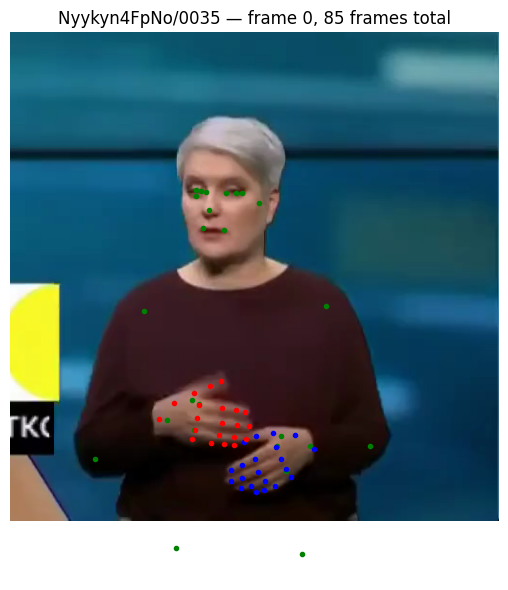

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

holistic_files = sorted(HOLISTIC_DIR.glob("*/*.npy"))

if holistic_files:
    sample_path = holistic_files[len(holistic_files) // 2]
    vid_id = sample_path.parent.name
    clip_name = sample_path.stem

    poses = np.load(sample_path)
    video_path = FEATURES_DIR / vid_id / f"{clip_name}.mp4"

    cap = cv2.VideoCapture(str(video_path))
    ret, frame = cap.read()
    cap.release()

    if ret:
        h, w = frame.shape[:2]
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Overlay first frame's joints (75 joints × 3)
        joints = poses[0].reshape(75, 3)
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        ax.imshow(frame_rgb)
        for j in range(75):
            x, y, vis = joints[j]
            if vis > 0.3:
                color = 'go' if j < 33 else ('bo' if j < 54 else 'ro')
                ax.plot(x * w, y * h, color, markersize=3)
        ax.set_title(f"{vid_id}/{clip_name} — frame 0, {poses.shape[0]} frames total")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

## 3. Package for Colab

Creates a zip of the prepared model directory (Data + Configs) for upload to Google Drive.

In [5]:
import subprocess

pt_dir = EXPERIMENT_DIR / "model"
zip_path = ROOT / "usl-pt-training-ready.zip"

subprocess.run(
    ["zip", "-r", "-q", str(zip_path), ".",
     "-x", "Models/*", "__pycache__/*", ".DS_Store"],
    cwd=str(pt_dir),
    check=True,
)

size_mb = zip_path.stat().st_size / (1024 * 1024)
print(f"Created {zip_path.name} ({size_mb:.1f} MB)")
print(f"Upload to Google Drive: MyDrive/ucu-text-to-sign/{zip_path.name}")

Created usl-pt-training-ready.zip (169.1 MB)
Upload to Google Drive: MyDrive/ucu-text-to-sign/usl-pt-training-ready.zip
